<a href="https://colab.research.google.com/github/LinearAlgebruh/PredictingMarchMadness/blob/main/PredictingWholeBrackets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
# Install Packages Here
import pandas as pd
import torch
%pip install pyreadr
import pyreadr
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [112]:
# Data Prep Methods
def readRSD(url, scratch):
  '''
  Reads in an RSD file from url and returns a dataframe.
  Scratch should be in ./_______.rda format.
  '''
  local = pyreadr.download_file(url, scratch)
  result = pyreadr.read_r(local)
  df = result[None]
  return df

def get_team_stats(df, team_id, year):
    """
    Returns all stats for a given team from a Detailed Results DataFrame,
    normalized to team/opponent perspective (instead of winner/loser).

    Parameters:
        df      : Detailed Results DataFrame
        team_id : The team's ID to filter by
        year    : (optional) Season year to filter by. If None, returns all years.

    Returns:
        DataFrame with one row per game, stats from the team's perspective
    """

    stat_cols = ['FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA',
                 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF']


    won = df[(df['WTeamID'] == team_id) & (df['Season'] == year)].copy()
    lost = df[(df['LTeamID'] == team_id) & (df['Season'] == year)].copy()

    # Games where team won
    won['TeamID']      = won['WTeamID']
    won['OpponentID']  = won['LTeamID']
    won['TeamScore']   = won['WScore']
    won['OppScore']    = won['LScore']
    won['Result']      = 1
    for col in stat_cols:
        won[col]           = won[f'W{col}']
        won[f'Opp{col}']   = won[f'L{col}']

    # Games where team lost
    lost['TeamID']     = lost['LTeamID']
    lost['OpponentID'] = lost['WTeamID']
    lost['TeamScore']  = lost['LScore']
    lost['OppScore']   = lost['WScore']
    lost['Result']     = 0
    for col in stat_cols:
        lost[col]          = lost[f'L{col}']
        lost[f'Opp{col}']  = lost[f'W{col}']

    # --- Combine and select final columns ---
    keep_cols = ['Season', 'DayNum', 'TeamID', 'OpponentID', 'TeamScore',
                 'OppScore', 'Result', 'NumOT'] + \
                stat_cols + [f'Opp{col}' for col in stat_cols]

    team_games = pd.concat([won, lost])[keep_cols]

    team_games = team_games.astype(float)

    team_games = team_games.sort_values(['Season', 'DayNum']).reset_index(drop=True)

    team_games = pd.concat([team_games, team_games.mean(axis=0).to_frame().T], ignore_index=True)


    return team_games

def get_tensor(df):
  '''
  Takes boxscore df  for a team over a season as input and returns a
  single tensor containing their season aggregated stats.
  '''
  df = df.drop(columns=['Season', 'DayNum', 'TeamID', 'OpponentID'])
  # convert to a NumPy array first
  stat_tensor = torch.tensor(df.iloc[-1].to_numpy(), dtype=torch.float32)
  return stat_tensor



# Get all results from 2003 onwards
def get_all_results(outcomes):
  '''
  Scrapes all game outcomes from df and returns a boolean vector of game outcomes.
  This method gives us our prediction targets. A value of 1 corresponds to the
  team with lower team ID winning and 0 to the team with higher team ID.
  Note that seeds are not a factor in determining 0 or 1, so this has nothing
  to do with seeding.
  '''
  outcomes = outcomes[outcomes['Season'] >= 2003] # Only have box score stats from 2003 onwards
  results = []
  for i in range(len(outcomes)):

    if outcomes.iloc[i]['WTeamID'] < outcomes.iloc[i]['LTeamID']:
      results.append(0)
    else:
      results.append(1)

  results = torch.tensor(results)
  return results


def gather_team_stats(outcomes,box_scores):
  '''
  Takes outcomes, a df containing each MM game's winner and loser, alongside
  box_scores, a df containing the box scores for all games from 2003 onwards,
  and combines them into a tensor where each row contains all season stats
  for two teams in the tournament. This method returns the X tensor we need
  for ML methods.
  '''
  outcomes = outcomes[outcomes['Season'] >= 2003]
  outcomes = outcomes[outcomes['DayNum'] != 2012]
  feature_list = []
  for i in range(len(outcomes)):

    team1 = min(outcomes['WTeamID'].iloc[i], outcomes['LTeamID'].iloc[i])
    team2 = max(outcomes['WTeamID'].iloc[i], outcomes['LTeamID'].iloc[i])

    df1 = get_team_stats(box_scores, team1, outcomes['Season'].iloc[i])
    df2 = get_team_stats(box_scores, team2, outcomes['Season'].iloc[i])

    tens1 = get_tensor(df1)
    tens2 = get_tensor(df2)
    # revise to use feature differences, not raw team stats
    tens = tens1 - tens2
    feature_list.append(tens)

  return torch.stack(feature_list)

# Read Files
outcomes = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/DataFiles/NCAATourneyCompactResults.rds', './TourneyResults.rda')
box_scores = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/Prelim2019_RegularSeasonDetailedResults.rds', './DetailedStats.rda')

# Assemble Data
X = gather_team_stats(outcomes, box_scores)
y = get_all_results(outcomes)

In [113]:
from torch import nn
import torch

class LogisticRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.layer1 = nn.Linear(n_features, 2)

    def forward(self, X):
        return self.layer1(X)

    def predict(self, X):
        return torch.argmax(self.forward(X), dim=1)

In [114]:
def train_model(model, X, y, n_epochs=5000):
    opt = torch.optim.SGD(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(n_epochs):
        opt.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y.long())
        losses.append(loss.item())
        loss.backward()
        opt.step()
    return losses



# Split data the same way as FirstPassClassification.ipynb
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# revised to standardize features
scaler = StandardScaler()

# convert to numpy for sklearn
X_train_np = X_train.numpy()
X_test_np  = X_test.numpy()

# fit on train, transform both
X_train = torch.tensor(scaler.fit_transform(X_train_np)).float()
X_test  = torch.tensor(scaler.transform(X_test_np)).float()

# Train on the training set
model = LogisticRegression(n_features=X_train.shape[1])
losses = train_model(model, X_train.float(), y_train.float())

# Evaluate on the test set
with torch.no_grad():
    logits = model(X_test.float())
    preds = torch.argmax(logits, dim=1)

print(accuracy_score(y_test, preds))

0.6857142857142857


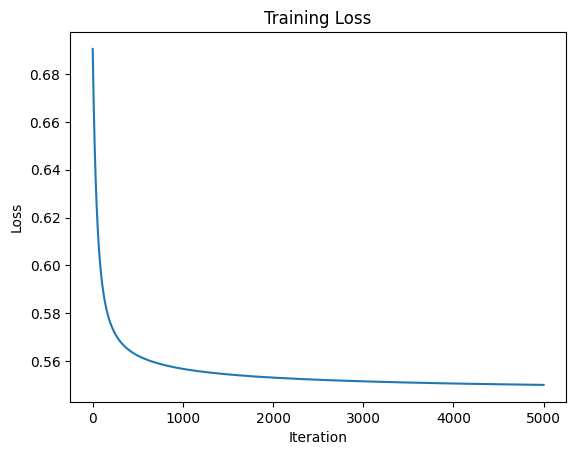

In [115]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [116]:
from os import read
# Used AI to scale idea to 6 Rounds

Outcomes = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/DataFiles/NCAATourneyCompactResults.rds', './TourneyResults.rda')
Seeds = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/DataFiles/NCAATourneySeeds.rds', './TourneySeeds.rda')
Slots = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/DataFiles/NCAATourneySeedRoundSlots.rds', './TourneySlots.rda')
box_scores = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/Prelim2019_RegularSeasonDetailedResults.rds', './DetailedStats.rda')


def predict_bracket(model, Season):

    # Select only the relevant season
    Outcomes_s = Outcomes[Outcomes['Season'] == Season]
    Seeds_s = Seeds[Seeds['Season'] == Season]
    Slots_s = Slots[Slots['GameRound'] >= 1] # Filter out play in Games

    first_round = Outcomes_s[-63:-31]

    seeding_dict = dict(zip(Seeds_s['TeamID'], Seeds_s['Seed']))
    matches_dict = Slots_s.groupby('Seed')['GameSlot'].apply(list).to_dict()

    # initialize with round 1 matchups
    current_round_teams = []
    for i in range(len(first_round)):
        team1 = min(first_round['WTeamID'].iloc[i], first_round['LTeamID'].iloc[i])
        team2 = max(first_round['WTeamID'].iloc[i], first_round['LTeamID'].iloc[i])
        current_round_teams.append([team1, team2])

    all_round_winners = []

    for round_idx in range(6):
        print(f"\n--- Round {round_idx + 1} ({len(current_round_teams)} games) ---")
        feature_list = []

        for team1, team2 in current_round_teams:
            df1 = get_team_stats(box_scores, team1, Season)
            df2 = get_team_stats(box_scores, team2, Season)

            tens1 = get_tensor(df1)
            tens2 = get_tensor(df2)
            tens = tens1 - tens2
            feature_list.append(tens)

        X = torch.stack(feature_list)
        # round_preds = model.predict(X)
        round_preds = model.predict(X)

        # get winner ids for this round
        winner_ids = [
            current_round_teams[i][round_preds[i].item()]
            for i in range(len(current_round_teams))
        ]
        all_round_winners.append(winner_ids)

        if round_idx == 5:
            print(f"\nChampion: {winner_ids[0]}")
            break

        # match winners into next round using game slots
        next_round_slots = {}
        for team_id in winner_ids:
            seed = seeding_dict[team_id]
            next_slot = matches_dict[seed][round_idx + 1]  # advance one round
            if next_slot not in next_round_slots:
                next_round_slots[next_slot] = []
            next_round_slots[next_slot].append(team_id)

        # build next round matchups
        current_round_teams = []
        for slot, teams in next_round_slots.items():
            if len(teams) != 2:
                print(f"Warning: slot {slot} has {len(teams)} teams, expected 2")
                continue
            team1 = min(teams)
            team2 = max(teams)
            current_round_teams.append([team1, team2])

    return all_round_winners


def sort_games(tourney_winners, Season):
  '''
  Takes in a list of game winners and returns a list with winning Team IDs
  oredered by round. This allows us to compare our results against real
  tournament years.
  '''
  # tourney_winners = [team for round_winners in tourney_winners for team in round_winners]
  tourney_winners = tourney_winners[-63:]  # then slice
  Slots = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/DataFiles/NCAATourneySeedRoundSlots.rds', './TourneySlots.rda')
  Seeds = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/DataFiles/NCAATourneySeeds.rds', './TourneySeeds.rda')
  # Filter
  Seeds = Seeds[Seeds['Season'] == Season]
  Slots = Slots[Slots['GameRound'] >= 1] # Filter out play in Games

  seeding_dict = dict(zip(Seeds['TeamID'], Seeds['Seed']))
  matches_dict = Slots.groupby('Seed')['GameSlot'].apply(list).to_dict()
  order_dict   = dict(zip(Slots['GameSlot'].unique(), [i for i in range(63)]))

  sorted_winners = [None for i in range(63)]
  round = 0
  for i in range(len(tourney_winners)):
    seed = seeding_dict[tourney_winners[i]]
    slot = matches_dict[seed]
    idx = order_dict[slot[round]]
    sorted_winners[idx] = tourney_winners[i]

    if i == 31:
      round = 1
    if i == 47:
      round = 2
    if i == 55:
      round = 3
    if i == 59:
      round = 4
    if i == 61:
      round = 5

  return sorted_winners

def score_bracket(preds, tests):
  score = 0
  for team in torch.unique(preds):
    n1 = torch.sum(tests == team).item()
    n2 = torch.sum(preds == team).item()
    n = min(n1, n2)
    print(team)
    print(n)
    score = score + (2 ** n - 1)
    print(score)

  return score



In [117]:
year = 2012

preds = predict_bracket(model, year)

lispreds = [team for round_winners in preds for team in round_winners]
  # tourney_winners = tourney_winners[-63:]

sorted_preds = torch.tensor(sort_games(lispreds,year))
ValOutcomes = Outcomes[Outcomes['Season'] == year]
ValOutcomes = ValOutcomes['WTeamID'].tolist()
print(type(ValOutcomes))
sorted_val = torch.tensor(sort_games(ValOutcomes, year))

print(torch.mean((sorted_preds == sorted_val).float()))


print(score_bracket(sorted_preds, sorted_val))


# print(torch.sum(sorted_preds == 1327))


# X.shape

# Slots = readRSD('https://github.com/kim3-sudo/march_madness_data/raw/refs/heads/main/DataFiles/NCAATourneySeedRoundSlots.rds', './TourneySlots.rda')
# Slots[Slots['GameRound'] >= 1].head()


--- Round 1 (32 games) ---

--- Round 2 (16 games) ---

--- Round 3 (8 games) ---

--- Round 4 (4 games) ---

--- Round 5 (2 games) ---

--- Round 6 (1 games) ---

Champion: 1246
<class 'list'>
tensor(0.5873)
tensor(1124, dtype=torch.int32)
1
1
tensor(1125, dtype=torch.int32)
0
1
tensor(1140, dtype=torch.int32)
0
1
tensor(1153, dtype=torch.int32)
2
4
tensor(1163, dtype=torch.int32)
0
4
tensor(1166, dtype=torch.int32)
1
5
tensor(1172, dtype=torch.int32)
0
5
tensor(1196, dtype=torch.int32)
1
6
tensor(1199, dtype=torch.int32)
1
7
tensor(1211, dtype=torch.int32)
1
8
tensor(1231, dtype=torch.int32)
1
9
tensor(1242, dtype=torch.int32)
2
12
tensor(1243, dtype=torch.int32)
1
13
tensor(1246, dtype=torch.int32)
6
76
tensor(1250, dtype=torch.int32)
1
77
tensor(1272, dtype=torch.int32)
0
77
tensor(1277, dtype=torch.int32)
2
80
tensor(1281, dtype=torch.int32)
0
80
tensor(1293, dtype=torch.int32)
1
81
tensor(1301, dtype=torch.int32)
1
82
tensor(1307, dtype=torch.int32)
1
83
tensor(1314, dtype=torch